<a href="https://colab.research.google.com/github/Tehreem31/Image-Classification/blob/main/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# CIFAR-10 Normalization Stats
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Download dataset into Colab storage
dataset_path = './data'
full_train_dataset = torchvision.datasets.CIFAR10(root=dataset_path, train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(root=dataset_path, train=False, download=True, transform=test_transform)

# 80/20 Train/Val Split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [44:19<00:00, 64.1kB/s]


In [3]:
class ImageClassifierNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ImageClassifierNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ImageClassifierNet(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [4]:
EPOCHS = 15
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = (correct.double() / total).item()

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = (val_correct.double() / val_total).item()

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

# Save model checkpoint locally in Colab
os.makedirs('./models', exist_ok=True)
torch.save(model.state_dict(), './models/cifar10_cnn_model.pth')
print("Model weight binary saved.")

Epoch [1/15] | Train Loss: 1.6442 Acc: 0.3964 | Val Loss: 1.2862 Acc: 0.5307
Epoch [2/15] | Train Loss: 1.3685 Acc: 0.5069 | Val Loss: 1.1066 Acc: 0.6092
Epoch [3/15] | Train Loss: 1.2543 Acc: 0.5525 | Val Loss: 1.0184 Acc: 0.6356
Epoch [4/15] | Train Loss: 1.1697 Acc: 0.5834 | Val Loss: 0.9652 Acc: 0.6562
Epoch [5/15] | Train Loss: 1.1174 Acc: 0.6044 | Val Loss: 0.9091 Acc: 0.6748
Epoch [6/15] | Train Loss: 1.0710 Acc: 0.6196 | Val Loss: 0.8721 Acc: 0.6904
Epoch [7/15] | Train Loss: 1.0368 Acc: 0.6361 | Val Loss: 0.8336 Acc: 0.7020
Epoch [8/15] | Train Loss: 1.0091 Acc: 0.6440 | Val Loss: 0.8163 Acc: 0.7068
Epoch [9/15] | Train Loss: 0.9726 Acc: 0.6561 | Val Loss: 0.7762 Acc: 0.7273
Epoch [10/15] | Train Loss: 0.9570 Acc: 0.6648 | Val Loss: 0.7547 Acc: 0.7357
Epoch [11/15] | Train Loss: 0.9321 Acc: 0.6733 | Val Loss: 0.7617 Acc: 0.7286
Epoch [12/15] | Train Loss: 0.9119 Acc: 0.6793 | Val Loss: 0.7337 Acc: 0.7381
Epoch [13/15] | Train Loss: 0.8990 Acc: 0.6844 | Val Loss: 0.7174 Acc: 0.

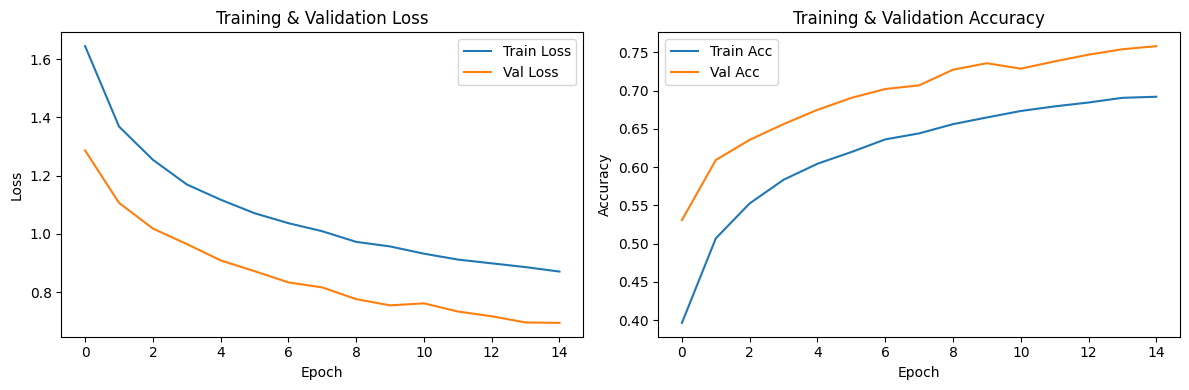


--- Classification Report ---
              precision    recall  f1-score   support

       plane       0.84      0.77      0.81      1000
         car       0.91      0.87      0.89      1000
        bird       0.72      0.57      0.63      1000
         cat       0.64      0.57      0.60      1000
        deer       0.74      0.75      0.75      1000
         dog       0.71      0.63      0.67      1000
        frog       0.66      0.93      0.77      1000
       horse       0.84      0.81      0.82      1000
        ship       0.85      0.90      0.87      1000
       truck       0.82      0.90      0.86      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



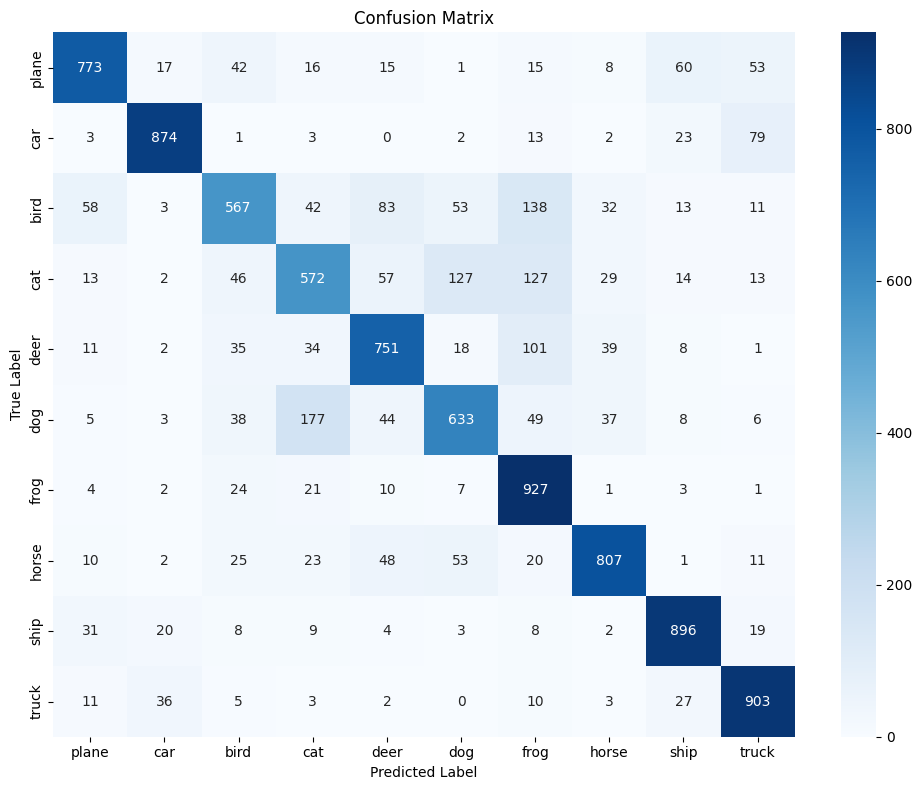

In [5]:
# Plot Loss & Accuracy Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('loss_accuracy_curves.png')
plt.show()

# Classification Report & Confusion Matrix
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()